<strong><span style="color:skyblue;font-size:40px"> Reinforcement Learning model for Quant analysis</strong><br>
- Data source from yahoo finance<br>
- train and test timer periods<br>
- Gymnasium for the model reward<br>

In [1]:
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import pandas as pd
import stable_baselines3 as sb3
import yfinance as yf
from stable_baselines3.common.env_checker import check_env
from stable_baselines3.common.monitor import Monitor
import os
import re
import gc
import json
results_dir = "./results"
os.makedirs(results_dir, exist_ok=True)
import glob
import torch
import random

device = 'cpu'

<strong><span style="color:lightgreen;font-size:30px">Agent environment Build</strong><br>
- Uses OpenAI's gymnasium space<br>
<span style="color:red">- Reward function requires work!</strong>

In [3]:
class IndexFundTradingEnv(gym.Env):
    def __init__(self, data, feature_cols=None):
        super(IndexFundTradingEnv, self).__init__()

        self.full_data = data.copy()
        self.tickers = sorted(list(self.full_data['Ticker'].unique())) # Sort for consistent order
        self.feature_cols = feature_cols or [col for col in self.full_data.select_dtypes(include=np.number).columns if col != 'Close']

        # --- OPTIMIZATION: Pre-process data into a dictionary of NumPy arrays ---
        self.data_dict = {}
        min_len = float('inf')

        for ticker in self.tickers:
            ticker_df = self.full_data[self.full_data['Ticker'] == ticker]
            min_len = min(min_len, len(ticker_df))
            
            # --- FIX 1: Clean NaN/inf values from features during pre-processing ---
            features_df = ticker_df[self.feature_cols].fillna(0).replace([np.inf, -np.inf], 0)

            self.data_dict[ticker] = {
                'features': features_df.to_numpy(dtype=np.float32),
                'close': ticker_df['Close'].to_numpy(dtype=np.float32)
            }
        
        # Trim all data to the length of the shortest ticker history
        self.max_steps = min_len
        for ticker in self.tickers:
            self.data_dict[ticker]['features'] = self.data_dict[ticker]['features'][:self.max_steps]
            self.data_dict[ticker]['close'] = self.data_dict[ticker]['close'][:self.max_steps]
        
        self.close_prices_matrix = np.array([self.data_dict[t]['close'] for t in self.tickers], dtype=np.float32)

        # --- Environment Configuration ---
        self.initial_cash = 10000.0
        self.weights = np.ones(len(self.tickers)) / len(self.tickers)

        self.action_space = spaces.Discrete(1)
        obs_size = len(self.feature_cols) * len(self.tickers) + len(self.tickers) + 1
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(obs_size,), dtype=np.float32)

        # This will be called at the end of __init__
        self.reset()

    def reset(self, *, seed=None, options=None):
        if seed is not None:
            super().reset(seed=seed)

        self.current_step = 0
        self.cash = 0.0
        self.action_history = []  # Add action history log

        initial_prices = self.close_prices_matrix[:, self.current_step]
        allocated_cash = self.initial_cash * self.weights

        self.holdings = allocated_cash // (initial_prices + 1e-9)
        self.portfolio_value_history = [self._get_portfolio_value(self.current_step)]

        return self._get_state(), {}

    def _get_state(self):
        features = np.concatenate([self.data_dict[t]['features'][self.current_step] for t in self.tickers])
        state = np.concatenate([features, self.holdings, [self.cash]], axis=0).astype(np.float32)
        return state

    def _get_portfolio_value(self, step):
        prices_at_step = self.close_prices_matrix[:, step]
        value = self.cash + np.dot(self.holdings, prices_at_step)
        return value

    def step(self, action):
        # The user's provided code implies they might be using a multi-action env now
        # Let's support both passive (action=0) and more complex actions
        if self.action_space.n == 1:
            assert action == 0, "This environment is passive-only."

        self.action_history.append(action.item() if isinstance(action, np.ndarray) else action)

        done = self.current_step >= self.max_steps - 2

        if done:
            obs = self._get_state()
            return obs, 0.0, True, False, {'portfolio_value': self._get_portfolio_value(self.current_step)}

        prev_value = self._get_portfolio_value(self.current_step)
        self.current_step += 1
        current_value = self._get_portfolio_value(self.current_step)

        reward = (current_value - prev_value) / (prev_value + 1e-9)
        self.portfolio_value_history.append(current_value)

        clipped_reward = float(np.clip(reward, -1.0, 1.0))
        obs = self._get_state()
        info = {'portfolio_value': current_value}

        return obs, clipped_reward, done, False, info

In [2]:
from stable_baselines3.common.callbacks import BaseCallback

class ProgressLoggerCallback(BaseCallback):
    def __init__(self, log_every: int = 500, verbose: int = 1):
        super().__init__(verbose)
        self.log_every = log_every

    def _on_step(self) -> bool:
        if self.n_calls % self.log_every == 0:
            logger.info(f"[{self.model.num_timesteps:,}] Timesteps processed")
        return True

In [3]:
class StockTradingEnv(gym.Env):
    def __init__(self, data, reward_params=None, feature_cols=None, multi_ticker=False):
        self.full_data = data.copy()
        self.multi_ticker = multi_ticker

        # Choose one ticker or use full dataset
        if multi_ticker:
            self.data = pd.DataFrame()  # Empty for now, selected at reset
        else:
            self.data = self.full_data
            self.ticker = self.data['Ticker'].iloc[0]
            self.ticker_id = hash(self.ticker) % 1000

        self.current_step = 0
        self.portfolio_history = []
        self.cash = 10000
        self.holdings = 0
        self.action_history = []
        self.portfolio_value_history = []

        for col in self.full_data.columns:
            self.full_data[col] = pd.to_numeric(self.full_data[col], errors='coerce')

        self.action_space = spaces.Discrete(3)

        self.numeric_cols = feature_cols or self.full_data.select_dtypes(include=np.number).columns

        # Observation space defined after we get the actual state
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(self.numeric_cols) + 2,), dtype=np.float32)

        default_params = {
            "trade_reward": 2,
            "profit_scaler": 50,
            "volatility_penalty": 2,
            "allocation_penalty_scale": 5
        }
        self.reward_params = reward_params or default_params

        # Only reset if not multi-ticker — avoid out-of-bounds on empty `self.data`
        if not self.multi_ticker:
            self.reset()

    def _get_state(self):
        row = self.data.iloc[self.current_step][self.numeric_cols]
        # print("🧪 Row type:", type(row))
        # print("📐 Row shape:", row.shape)
        # print("🔢 Row preview:", row.head() if hasattr(row, "head") else row)
        cleaned = row.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)  # 🧼 Explicit cast
        state = np.concatenate([cleaned.values, [self.cash, self.holdings]], axis=0)
        return state
    
    def step(self, action):
        self.action_history.append(int(action))
        price = self.data.iloc[self.current_step]['Close']
        portfolio_value = self.cash + self.holdings * price
        self.portfolio_value_history.append(portfolio_value)
        if action in [1, 2]:
            self.trade_log.append({
                "step": self.current_step,
                "action": int(action),
                "price": price,
                "cash": self.cash,
                "holdings": self.holdings
            })
        # Reward based on the current action
        reward = self.calculate_reward(action)
        # Advance to the next time step
        self.current_step += 1
        # Check if we’re done (end of the data)
        terminated = self.current_step >= len(self.data) - 1
        truncated = False  # Could be used for time limits, etc.
        # Get the next state observation
        observation = self._get_state()
        # Info dict — can be used for debugging, analytics, etc.
        info = {"portfolio_value": self.cash + self.holdings * self.data.iloc[self.current_step]['Close'],}
        return observation, reward, terminated, truncated, info

    def calculate_reward(self, action):
        """
        Balanced reward function:
        - Only rewards trade if it leads to profit (real or potential)
        - Encourages holding during calm periods
        - Penalizes unnecessary risk or allocation imbalance
        """

        price = self.data.iloc[self.current_step]['Close']
        prev_price = self.data.iloc[self.current_step - 1]['Close'] if self.current_step > 0 else price
        prev_portfolio_value = self.cash + self.holdings * price
        prev_allocation = (self.holdings * price) / (prev_portfolio_value + 1e-8)
        transaction_cost = price * 0.001
        reward = 0.0

        # Save portfolio value before the action
        prev_portfolio_value = self.cash + self.holdings * price

        # Simulate action
        if action == 1 and self.cash >= price + transaction_cost:
            self.holdings += 1
            self.cash -= price + transaction_cost
            self.last_buy_price = price  # ✅ new
        elif action == 2 and self.holdings > 0:
            self.holdings -= 1
            self.cash += price - transaction_cost
            if hasattr(self, 'last_buy_price'):
                profit = price - self.last_buy_price
                if profit > 0:
                    reward += profit * 2  # 🔧 amplify reward
                else:
                    reward += profit * 1.5  # soften punishment

        elif action == 2 and self.holdings > 0:
            # Sell
            self.holdings -= 1
            self.cash += price - transaction_cost

        # After-action portfolio
        new_portfolio_value = self.cash + self.holdings * price
        portfolio_change = (new_portfolio_value - prev_portfolio_value) / (prev_portfolio_value + 1e-8)

        # Reward is primarily driven by profit
        reward += self.reward_params["profit_scaler"] * portfolio_change

        # Encourage holding if price is stable (low volatility)
        price_change_pct = abs(price - prev_price) / (prev_price + 1e-8)
        if action == 0 and price_change_pct < 0.002:  # < 0.2% change
            reward += 0.1  # small bonus for sensible inactivity

        # Penalize if too much cash or too much stock (over-skew)
        total_value = self.cash + self.holdings * price
        allocation = (self.holdings * price) / (total_value + 1e-8)
        if prev_allocation < 0.05 and allocation >= 0.1:
            reward += 0.5  # ✅ Encourages entering the market
        elif allocation > 0.95 or allocation < 0.05:
            reward -= self.reward_params["allocation_penalty_scale"] * abs(allocation - 0.5)

        invalid_action_penalty = -1  # 🔧 tune this!

        if action == 1 and self.cash < price + transaction_cost:
            reward += invalid_action_penalty
        elif action == 2 and self.holdings <= 0:
            reward += invalid_action_penalty
        elif action == 0 and self.holdings == 0:
            reward += invalid_action_penalty * 0.5

        profit_change = (new_portfolio_value - prev_portfolio_value) / (prev_portfolio_value + 1e-8)
        reward += profit_change * self.reward_params["profit_scaler"]

        # Add volatility penalty if recent portfolio value has been erratic
        self.portfolio_history.append(new_portfolio_value)
        if len(self.portfolio_history) > 10:
            recent_vol = np.std(self.portfolio_history[-10:])
            reward -= self.reward_params["volatility_penalty"] * recent_vol
        if abs(reward) > 50 or self.current_step % 500 == 0:
            print(f"[Step {self.current_step}] Action: {action} | Reward: {reward:.2f} | Allocation: {allocation:.2f}")
        return float(np.clip(reward, -20, 20))

    def log_action_distribution(self):
        import collections
        counts = collections.Counter(self.action_history)
        total = sum(counts.values()) or 1  # Avoid divide-by-zero
        print("Action Distribution:")
        for action in range(3):
            label = ['Hold', 'Buy', 'Sell'][action]
            pct = counts[action] / total
            print(f"  Action {action} ({label}): {counts[action]} ({pct:.2%})")


    def reset(self, *, seed=None, options=None):
        self.action_history = []
        self.portfolio_value_history = []
        self.trade_log = []

        if self.multi_ticker:
            available = self.full_data['Ticker'].unique()
            self.current_ticker = np.random.choice(available)
            self.data = self.full_data[self.full_data['Ticker'] == self.current_ticker].reset_index(drop=True)
            print(f"🔁 New episode using ticker: {self.current_ticker}")

        if len(self.data) == 0:
            raise ValueError("Environment reset with empty data.")

        self.current_step = 0
        self.cash = 10000
        self.holdings = 0

        if seed is not None:
            np.random.seed(seed)

        return self._get_state(), {}

Financial moddeling functions

In [6]:
def rolling_statistics(data, window):
    """
    Calculates rolling statistics given a series of data and window size.
    Returns: Rolling Max, Min, Standard deviation, Average
    Parameters:
        data: Pandas Series
        window: int, length of rolling window
    """
    rolling_max = data.rolling(window=window).max()
    rolling_min = data.rolling(window=window).min()
    rolling_std = data.rolling(window=window).std()
    rolling_average = data.rolling(window=window).mean()
    return rolling_max, rolling_min, rolling_std, rolling_average

def rsi (data,window):
    """
    calcualtes the RSI score (Relative Strength Index) for a given data series
    :paramaters
        data: pandas Series
        Window: int, length of rolling window
    """
    delta = data.diff()
    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta > 0, 0)
    avg_gain = gain.rolling(window=window).mean()
    avg_loss = loss.rolling(window=window).mean()
    rs = avg_gain/(avg_loss + 1e-10)  # Avoid division by zero
    rsi = 100 - (100 / (1+rs))
    return rsi

def macd(data, short_window, long_window, signal_window):
    """
    Moving Average Convergence Divergence (MACD) calculation.
    Meansures trend strength and direction.
    Paramenters:
        data: Pandas Series
        short_window: int, short-term moving average window - recomended = 12
        long_window: int, Long-term moving average window - recomended = 26
        signal_window: int, Signal line moving average window - recomended = 9
    Retuerns:
        MACD_line:Pandas Series
        Signal_line: Pandas Series
    """
    ema_short = data.ewm(span=short_window, adjust=False).mean()
    ema_long = data.ewm(span=long_window, adjust=False).mean()
    macd_line = ema_short - ema_long
    macd_signal = macd_line.ewm(span=signal_window, adjust=False).mean()
    return macd_line, macd_signal


<strong><span style="font-size:30px;color:lightpink">download stocks data from yfinance ready for analysis</strong><br>
| Ticker  | Company Name            |
|---------|------------------------|
| TSLA    | Tesla Inc              |
| NVDA    | NVIDIA Corporation     |
| PG      | Procter & Gamble Co    |
| BARC.L  | Barclays PLC           |
| EZJ.L   | EasyJet PLC            |
| BA.L    | BAE Systems PLC        |

In [2]:
tickers = [ 
    'III.L', 'ADM.L', 'AAF.L', 'ALW.L', 'AAL.L', 'ANTO.L', 'AHT.L', 'ABF.L', 'AZN.L', 'AUTO.L',
    'AV.L', 'BAB.L', 'BA.L', 'BARC.L', 'BTRW.L', 'BEZ.L', 'BKG.L', 'BP.L', 'BATS.L', 'BT-A.L',
    'BNZL.L', 'CNA.L', 'CCEP.L', 'CCH.L', 'CPG.L', 'CTEC.L', 'CRDA.L', 'DCC.L', 'DGE.L', 'DPLM.L',
    'EDV.L', 'ENT.L', 'EZJ.L', 'EXPN.L', 'FCIT.L', 'FRES.L', 'GAW.L', 'GLEN.L', 'GSK.L', 'HLN.L',
    'HLMA.L', 'HIK.L', 'HSX.L', 'HWDN.L', 'HSBA.L', 'IHG.L', 'IMI.L', 'IMB.L', 'INF.L', 'ICG.L',
    'IAG.L', 'ITRK.L', 'JD.L', 'KGF.L', 'LAND.L', 'LGEN.L', 'LLOY.L', 'LMP.L', 'MNG.L', 'MKS.L',
    'MRO.L', 'MNDI.L', 'NG.L', 'NWG.L', 'NXT.L', 'PSON.L', 'PSH.L', 'PSN.L', 'PHNX.L', 'PCT.L',
    'PRU.L', 'RKT.L', 'REL.L', 'RTO.L', 'RMV.L', 'RIO.L', 'RR.L', 'SGE.L', 'SBRY.L', 'SDR.L',
    'SMT.L', 'SGRO.L', 'SVT.L', 'SHEL.L', 'SMIN.L', 'SN.L', 'SPX.L', 'SSE.L', 'STJ.L', 'STAN.L',
    'TW.L', 'TSCO.L', 'ULVR.L', 'UTG.L', 'UU.L', 'VOD.L', 'WEIR.L', 'WTB.L', 'WPP.L'
    ]
print("Downloading data stocks data...")
data = yf.download(tickers= tickers, start='2018-01-01', end='2024-12-31', group_by='ticker')
print("stocks data downloaded.")
# reshare the data to be multi idex table
data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()
# convert to ordered by ticker then date
data = data.sort_values(by=['Ticker', 'Date'])
print(data.dtypes)


training_data = data[data['Date'] < '2022-01-01']
testing_data = data[data['Date'] >= '2022-01-01']

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  99 of 99 completed
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_40744/4047510930.py:17: FutureWarning: The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.
  data = data.stack(level=0).rename_axis(['Date', 'Ticker']).reset_index()


stocks data downloaded.
Price
Date      datetime64[ns]
Ticker            object
Open             float64
High             float64
Low              float64
Close            float64
Volume           float64
dtype: object


In [15]:
features = ['Open', 'High', 'Low', 'Close', 'Volume']
processed_data = []

for symbol in tickers:
    print(f"📈 Processing features for {symbol}...")
    
    # Extract and sort data for this symbol
    symbol_df = training_data[training_data['Ticker'] == symbol].copy()
    symbol_df = symbol_df.sort_values(by="Date")
    
    # Generate technical indicators
    for feature in features:
        rolling_max, rolling_min, rolling_std, rolling_avg = rolling_statistics(symbol_df[feature], window=21)
        symbol_df[f'{feature}_rolling_max_21'] = rolling_max
        symbol_df[f'{feature}_rolling_min_21'] = rolling_min
        symbol_df[f'{feature}_rolling_std_21'] = rolling_std
        symbol_df[f'{feature}_rolling_avg_21'] = rolling_avg
        
        symbol_df[f'{feature}_rsi'] = rsi(symbol_df[feature], window=14)
        macd_line, macd_signal = macd(symbol_df[feature], short_window=12, long_window=26, signal_window=9)
        symbol_df[f'{feature}_macd'] = macd_line
        symbol_df[f'{feature}_macd_signal'] = macd_signal

    # Keep only the features we need
    symbol_df = symbol_df[['Ticker', 'Date', 'Close', 'Volume', 'Close_rolling_max_21',
                           'Close_rolling_min_21', 'Close_rolling_std_21', 'Close_rolling_avg_21',
                           'Close_rsi', 'Close_macd', 'Close_macd_signal']].copy()

    processed_data.append(symbol_df)

# Combine all tickers' data
symbol_data = pd.concat(processed_data, axis=0)
symbol_data = symbol_data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

# (Optional) Save or preview
print("✅ Data ready for training:")
display(symbol_data.head())
print(symbol_data.columns)

# Save log
log_dir = "/Users/zacwells/Desktop/Reinforcement_Learning_stock_trading_env.csv"
os.makedirs(os.path.dirname(log_dir), exist_ok=True)
symbol_data.to_csv(log_dir, index=False)

📈 Processing features for BTC-USD...
✅ Data ready for training:


Price,Ticker,Date,Close,Volume,Close_rolling_max_21,Close_rolling_min_21,Close_rolling_std_21,Close_rolling_avg_21,Close_rsi,Close_macd,Close_macd_signal
0,BTC-USD,2018-01-01,13657.200195,10291200000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
1,BTC-USD,2018-01-02,14982.099609,16846600192,NaN,NaN,NaN,NaN,NaN,105.689982,21.137996
2,BTC-USD,2018-01-03,15201.000000,16871900160,NaN,NaN,NaN,NaN,NaN,204.753218,57.861041
3,BTC-USD,2018-01-04,15599.200195,21783199744,NaN,NaN,NaN,NaN,NaN,311.798753,108.648583
4,BTC-USD,2018-01-05,17429.500000,23840899072,NaN,NaN,NaN,NaN,NaN,538.119897,194.542846


Index(['Ticker', 'Date', 'Close', 'Volume', 'Close_rolling_max_21',
       'Close_rolling_min_21', 'Close_rolling_std_21', 'Close_rolling_avg_21',
       'Close_rsi', 'Close_macd', 'Close_macd_signal'],
      dtype='object', name='Price')


In [16]:
import os
import re
import gc
import json
import logging
import numpy as np
import pandas as pd # Make sure pandas is imported
import matplotlib.pyplot as plt
from typing import List, Tuple, Dict, Any

from stable_baselines3 import PPO
# --- OPTIMIZATION: Import SubprocVecEnv ---
from stable_baselines3.common.vec_env import DummyVecEnv, SubprocVecEnv
from stable_baselines3.common.env_util import make_vec_env

import torch

# It's good practice to set the device once
device = "cuda" if torch.cuda.is_available() else "cpu"

# --- Main training function modified for parallelization ---
def train_with_checkpoints(config, train_data, reward_params, n_envs=4, device=device) -> List[Tuple[int, str]]:
    model_name = f"{config['name'].replace(' ', '_')}_{reward_params['name']}"
    
    # --- OPTIMIZATION: Use make_vec_env to create parallel environments ---
    logger.info(f"Creating {n_envs} parallel environments for {model_name} on {device.upper()}")
    # Use SubprocVecEnv for true parallelism, requires the if __name__ == '__main__': guard
    env = make_vec_env(IndexFundTradingEnv, n_envs=n_envs, vec_env_cls=SubprocVecEnv, env_kwargs={'data': train_data})

    # The PPO model automatically handles the vectorized environment
    model = PPO("MlpPolicy", env, device=device, verbose=1, **config["kwargs"])
    logger.info(f"Confirmed model running on: {model.device}")

    # The rest of your training loop is fine, but you might need to adjust total_timesteps
    # as they are now spread across n_envs. SB3 handles this calculation correctly.
    # For example, 100,000 total_timesteps with 4 envs means each env runs for ~25,000 steps.
    
    results = []
    # Let's track progress from 0
    last_checkpoint = 0
    for step_goal in checkpoints:
        # Timesteps to train for this iteration
        timesteps_to_train = step_goal - last_checkpoint
        if timesteps_to_train <= 0:
            continue

        model_path = os.path.join(checkpoint_dir, f"{model_name}_{step_goal}_steps.zip")
        if os.path.exists(model_path) and not replace_models:
            logger.info(f"Skipping {model_name} at {step_goal} steps (exists).")
            # Need to load the model to continue training from this checkpoint
            model = PPO.load(model_path, env=env)
            results.append((step_goal, model_path))
            last_checkpoint = step_goal
            continue

        logger.info(f"Training {model_name} for an additional {timesteps_to_train} steps to reach {step_goal}...")
        # No need for a custom callback for logging, PPO's verbose=1 does a good job.
        model.learn(total_timesteps=timesteps_to_train)
        model.save(model_path)
        logger.info(f"✅ Saved model to {model_path}")
        results.append((step_goal, model_path))
        last_checkpoint = step_goal
        gc.collect()

    env.close()
    del model, env
    gc.collect()
    return results

# === Main Execution Guard ===
# IMPORTANT: Multiprocessing with SubprocVecEnv requires this guard
if __name__ == '__main__':
    # Assume symbol_data is loaded here, e.g.,
    # symbol_data = pd.read_csv('your_data.csv') 

    # === Logging Setup (as before) ===
    logging.basicConfig(
        level=logging.INFO,
        format='[%(asctime)s] %(levelname)s - %(message)s',
        datefmt='%H:%M:%S'
    )
    logger = logging.getLogger(__name__)

    replace_models = True
    results_dir = "./results"
    checkpoint_dir = "./checkpoints"
    os.makedirs(results_dir, exist_ok=True)
    os.makedirs(checkpoint_dir, exist_ok=True)

    reward_sweeps = [{"name": "Vanilla"}]
    model_configs = [{"name": "Vanilla PPO", "kwargs": {}}]
    checkpoints = [100_000, 500_000, 1_000_000, 5_000_000] # Example checkpoints

    # Your evaluation and plotting functions (make_json_safe, evaluate_checkpoint, plot_portfolio_growth)
    # do not need significant changes, but your evaluation env should also be the new optimized one.

    for sweep in reward_sweeps:
        for config in model_configs:
            logger.info(f"📦 Starting: {config['name']} – {sweep['name']}")
            # assert len(symbol_data) > 0, "⚠️ symbol_data is empty!"

            # Set the number of parallel environments based on your CPU cores
            # A good starting point is os.cpu_count() - 1
            num_cpu = max(1, os.cpu_count() - 1) 

            checkpoints_info = train_with_checkpoints(config, symbol_data, sweep, n_envs=num_cpu, device=device)

            # ... (Your evaluation and plotting loop remains largely the same)
            # ... just make sure `evaluate_checkpoint` uses the new `IndexFundTradingEnv`
            
    logger.info("✅ All training and evaluation complete.")

[20:54:39] INFO - 📦 Starting: Vanilla PPO – Vanilla
[20:54:39] INFO - Creating 9 parallel environments for Vanilla_PPO_Vanilla on CPU
[20:54:46] INFO - Confirmed model running on: cpu
[20:54:46] INFO - Training Vanilla_PPO_Vanilla for an additional 100000 steps to reach 100000...


Using cpu device
---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.46e+03 |
|    ep_rew_mean     | 0        |
| time/              |          |
|    fps             | 28352    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 18432    |
---------------------------------
--------------------------------------
| rollout/                |          |
|    ep_len_mean          | 1.46e+03 |
|    ep_rew_mean          | 0        |
| time/                   |          |
|    fps                  | 10755    |
|    iterations           | 2        |
|    time_elapsed         | 3        |
|    total_timesteps      | 36864    |
| train/                  |          |
|    approx_kl            | 0.0      |
|    clip_fraction        | 0        |
|    clip_range           | 0.2      |
|    entropy_loss         | 0        |
|    explained_variance   | -6.37    |
|    learning_rate        | 0.0003   |
|    loss          

[20:55:04] INFO - ✅ Saved model to ./checkpoints/Vanilla_PPO_Vanilla_100000_steps.zip
[20:55:04] INFO - Training Vanilla_PPO_Vanilla for an additional 400000 steps to reach 500000...


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.46e+03 |
|    ep_rew_mean     | 0        |
| time/              |          |
|    fps             | 29553    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 18432    |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 1.46e+03  |
|    ep_rew_mean          | 0         |
| time/                   |           |
|    fps                  | 11018     |
|    iterations           | 2         |
|    time_elapsed         | 3         |
|    total_timesteps      | 36864     |
| train/                  |           |
|    approx_kl            | 0.0       |
|    clip_fraction        | 0         |
|    clip_range           | 0.2       |
|    entropy_loss         | 0         |
|    explained_variance   | -0.00277  |
|    learning_rate        | 0.0003    |
|    loss           

[20:56:04] INFO - ✅ Saved model to ./checkpoints/Vanilla_PPO_Vanilla_500000_steps.zip
[20:56:05] INFO - Training Vanilla_PPO_Vanilla for an additional 500000 steps to reach 1000000...


---------------------------------
| rollout/           |          |
|    ep_len_mean     | 1.46e+03 |
|    ep_rew_mean     | 0        |
| time/              |          |
|    fps             | 29864    |
|    iterations      | 1        |
|    time_elapsed    | 0        |
|    total_timesteps | 18432    |
---------------------------------
---------------------------------------
| rollout/                |           |
|    ep_len_mean          | 1.46e+03  |
|    ep_rew_mean          | 0         |
| time/                   |           |
|    fps                  | 11062     |
|    iterations           | 2         |
|    time_elapsed         | 3         |
|    total_timesteps      | 36864     |
| train/                  |           |
|    approx_kl            | 0.0       |
|    clip_fraction        | 0         |
|    clip_range           | 0.2       |
|    entropy_loss         | 0         |
|    explained_variance   | -1.38     |
|    learning_rate        | 0.0003    |
|    loss           

KeyboardInterrupt: 

<strong><span style="font-size:40px;color:orange">Model Testing on other datasets</strong><br>

In [ ]:
print("🔍 Building index-style FTSE 100 test dataset...")

# Build index-like test data
index_like_test_data = []

for ticker in testing_data['Ticker'].unique():
    ticker_df = testing_data[testing_data['Ticker'] == ticker].copy()

    for feature in features:
        rolling_max, rolling_min, rolling_std, rolling_avg = rolling_statistics(ticker_df[feature], window=21)
        ticker_df[feature + '_rolling_max_21'] = rolling_max
        ticker_df[feature + '_rolling_min_21'] = rolling_min
        ticker_df[feature + '_rolling_std_21'] = rolling_std
        ticker_df[feature + '_rolling_avg_21'] = rolling_avg

        ticker_df[feature + '_rsi'] = rsi(ticker_df[feature], window=14)
        macd_line, macd_signal = macd(ticker_df[feature], short_window=12, long_window=26, signal_window=9)
        ticker_df[feature + '_macd'] = macd_line
        ticker_df[feature + '_macd_signal'] = macd_signal

    index_like_test_data.append(ticker_df)

# ✅ Combine all tickers into one DataFrame
index_fund_test_data = pd.concat(index_like_test_data)
index_fund_test_data = index_fund_test_data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)

# ✅ Final features subset
index_fund_test_data = index_fund_test_data[[
    'Date', 'Ticker', 'Close', 'Volume',
    'Close_rolling_max_21', 'Close_rolling_min_21',
    'Close_rolling_std_21', 'Close_rolling_avg_21',
    'Close_rsi', 'Close_macd', 'Close_macd_signal'
]].copy()

print("✅ Index-style test dataset ready.")
print(index_fund_test_data.head())

# ✅ Now fix your loop — treat df as a DataFrame, not a dictionary!
# Convert the single DataFrame into a dict of DataFrames per ticker
index_fund_test_data_dict = {
    ticker: group.reset_index(drop=True)
    for ticker, group in index_fund_test_data.groupby('Ticker')
}

# ✅ Clean column names and ensure 'Ticker' exists
for name, df in index_fund_test_data_dict.items():
    df.columns.name = None  # Remove column name if it exists
    if 'Ticker' not in df.columns:
        df['Ticker'] = name
    index_fund_test_data_dict[name] = df  # update

🔍 Building index-style FTSE 100 test dataset...
✅ Index-style test dataset ready.
Price       Date Ticker       Close     Volume  Close_rolling_max_21  \
0     2022-01-04  AAF.L  141.069199  3719444.0                   NaN   
1     2022-01-05  AAF.L  140.869232  2336920.0                   NaN   
2     2022-01-06  AAF.L  136.970093  1091544.0                   NaN   
3     2022-01-07  AAF.L  138.869675  1299995.0                   NaN   
4     2022-01-10  AAF.L  134.570618  1773000.0                   NaN   

Price  Close_rolling_min_21  Close_rolling_std_21  Close_rolling_avg_21  \
0                       NaN                   NaN                   NaN   
1                       NaN                   NaN                   NaN   
2                       NaN                   NaN                   NaN   
3                       NaN                   NaN                   NaN   
4                       NaN                   NaN                   NaN   

Price  Close_rsi  Close_macd  Clos


Initial `testing_data` DataFrame before feature engineering:
        Date Ticker       Close     Volume  Close_rolling_max_21  \
0 2022-01-04  AAF.L  141.069199  3719444.0                   NaN   
1 2022-01-05  AAF.L  140.869232  2336920.0                   NaN   
2 2022-01-06  AAF.L  136.970093  1091544.0                   NaN   
3 2022-01-07  AAF.L  138.869675  1299995.0                   NaN   
4 2022-01-10  AAF.L  134.570618  1773000.0                   NaN   

   Close_rolling_min_21  Close_rolling_std_21  Close_rolling_avg_21  \
0                   NaN                   NaN                   NaN   
1                   NaN                   NaN                   NaN   
2                   NaN                   NaN                   NaN   
3                   NaN                   NaN                   NaN   
4                   NaN                   NaN                   NaN   

   Close_rsi  Close_macd  Close_macd_signal  
0        NaN    0.000000           0.000000  
1        N

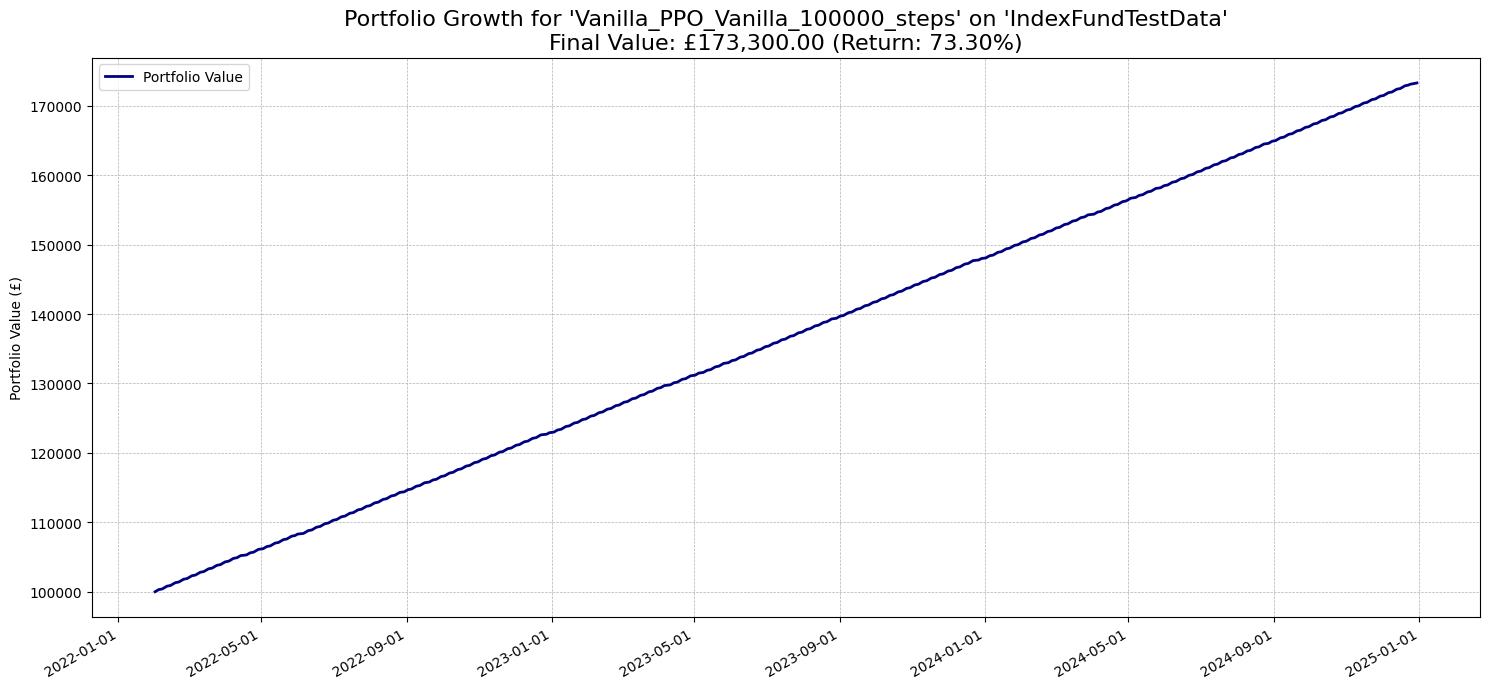


Testing model: ./checkpoints/Vanilla_PPO_Vanilla_200000_steps.zip
 → On test set: 'IndexFundTestData' (72520 rows)
Loading model from ./checkpoints/Vanilla_PPO_Vanilla_200000_steps.zip...
✅ Inferred that the model was trained on 88 tickers.
Test data has 99 tickers. Filtering to match model's expected 88.
--------------------------------------------------
🧾 Evaluation Summary for: Vanilla_PPO_Vanilla_200000_steps
  Initial Portfolio Value: £100,000.00
  Final Portfolio Value:   £173,300.00
  Net Return:              73.30%
  Action Counts: Holds=734, Buys=0, Sells=0
--------------------------------------------------


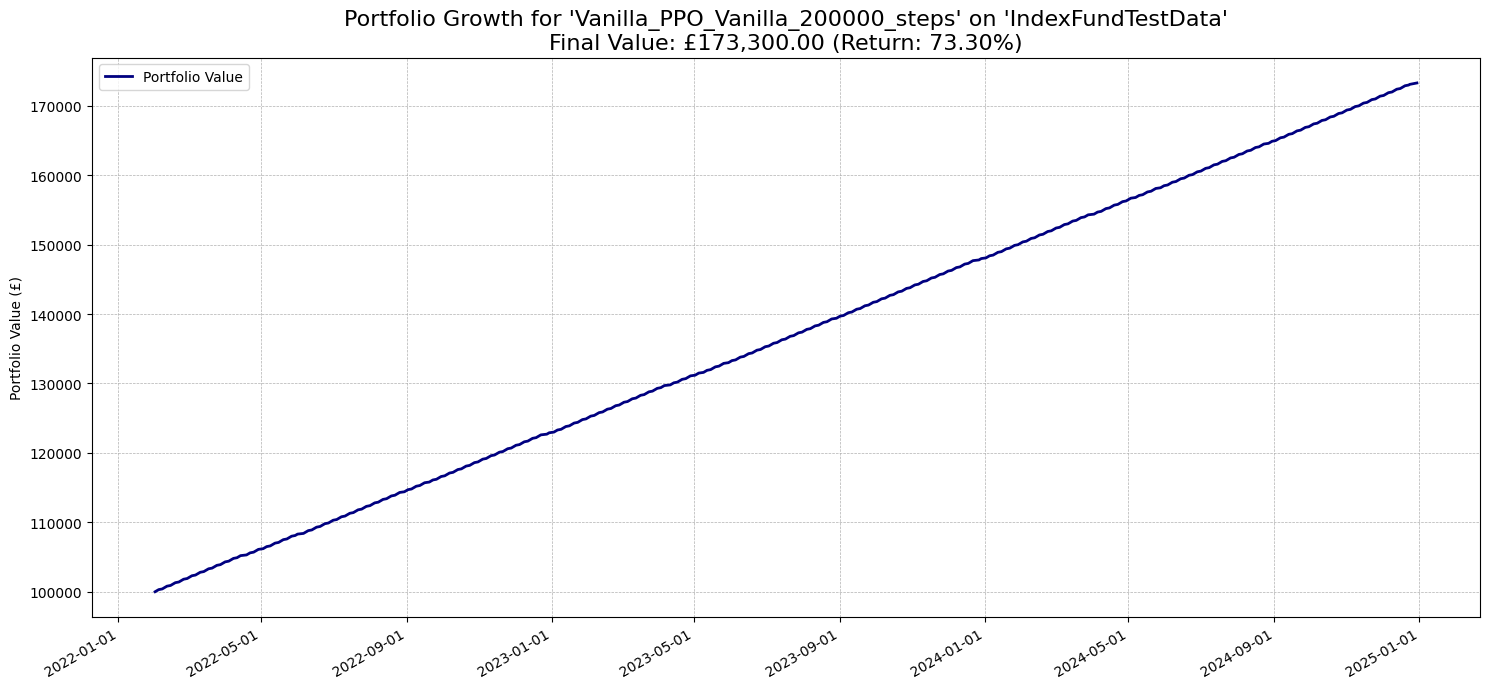


Testing model: ./checkpoints/Vanilla_PPO_Vanilla_500000_steps.zip
 → On test set: 'IndexFundTestData' (72520 rows)
Loading model from ./checkpoints/Vanilla_PPO_Vanilla_500000_steps.zip...
✅ Inferred that the model was trained on 88 tickers.
Test data has 99 tickers. Filtering to match model's expected 88.
--------------------------------------------------
🧾 Evaluation Summary for: Vanilla_PPO_Vanilla_500000_steps
  Initial Portfolio Value: £100,000.00
  Final Portfolio Value:   £173,300.00
  Net Return:              73.30%
  Action Counts: Holds=734, Buys=0, Sells=0
--------------------------------------------------


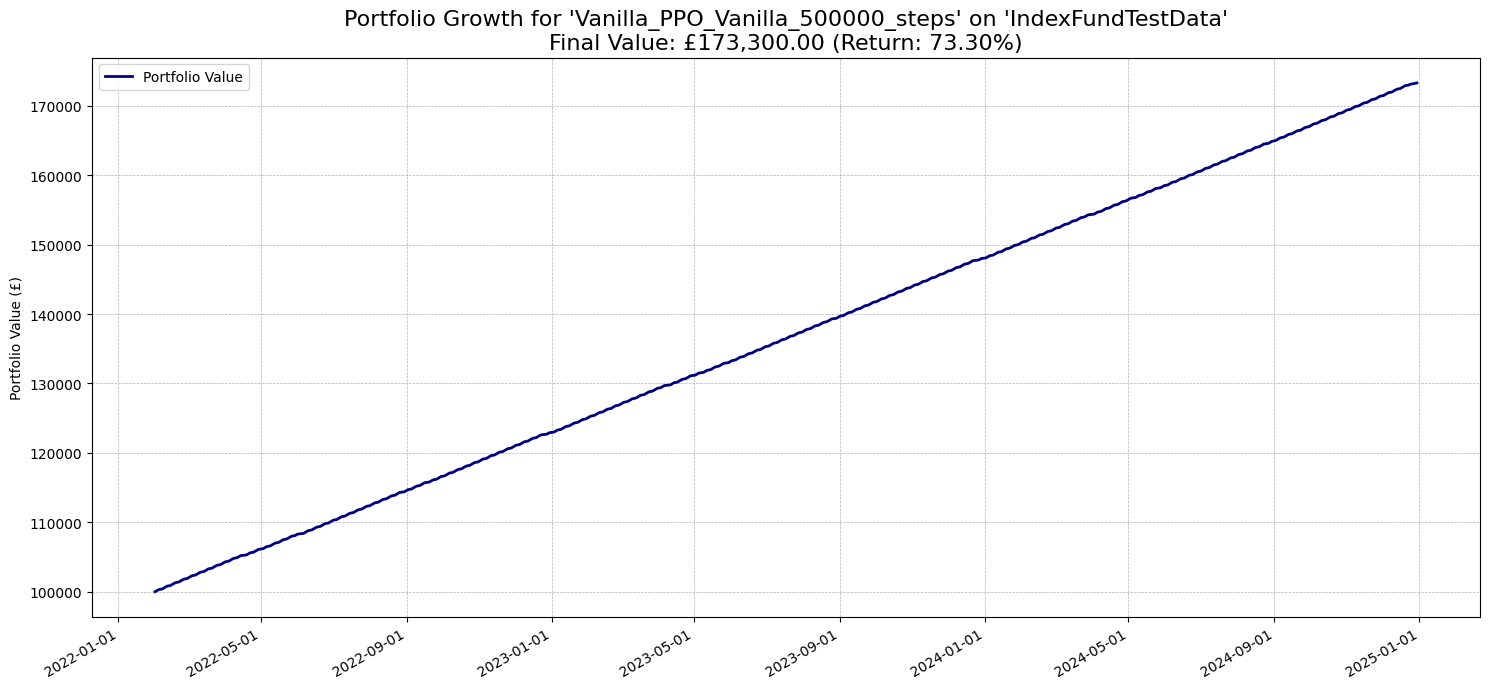


✅ Test suite complete. Total results generated: 3


In [ ]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from stable_baselines3 import PPO

# --- Define the feature set used during training ---
# These are the columns the environment will use to build the observation state.
# We exclude non-numeric identifiers like 'Ticker' and 'Date'.
feature_cols = [
    'Close', 'Volume', 'Close_rolling_max_21', 'Close_rolling_min_21',
    'Close_rolling_std_21', 'Close_rolling_avg_21', 'Close_rsi',
    'Close_macd', 'Close_macd_signal'
]

# --- Load Model (no changes needed) ---
def load_model(path):
    """Loads a PPO model from the specified path."""
    print(f"Loading model from {path}...")
    return PPO.load(path)

# --- Plotting Function for Portfolio Growth (no changes needed) ---
def plot_portfolio_growth(result, test_label):
    """
    Plots the portfolio value over time.
    """
    fig, ax = plt.subplots(figsize=(15, 7))

    # Use dates for the x-axis if available
    if result.get("dates") and not pd.Series(result["dates"]).isna().all():
        dates = pd.to_datetime(result["dates"])
        ax.plot(dates, result["portfolio"], label="Portfolio Value", color="navy", linewidth=2)
        # Format the x-axis to show dates nicely
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
        ax.xaxis.set_major_locator(mdates.AutoDateLocator())
        fig.autofmt_xdate() # Rotates dates for readability
    else:
        # Fallback to using steps if no dates are present
        ax.plot(result["portfolio"], label="Portfolio Value", color="navy", linewidth=2)
        ax.set_xlabel("Time Step")

    initial_value = result["portfolio"][0]
    final_value = result["final_value"]
    return_pct = (final_value - initial_value) / initial_value * 100

    ax.set_title(
        f"Portfolio Growth for '{result['name']}' on '{test_label}'\n"
        f"Final Value: £{final_value:,.2f} (Return: {return_pct:.2f}%)",
        fontsize=16
    )
    ax.set_ylabel("Portfolio Value (£)")
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.legend()
    plt.tight_layout()
    plt.show()
    return fig


# --- REVISED: Evaluation Function with Integrated Fix ---
def evaluate_on_test(model_path, test_data, env_class):
    """
    Evaluates a trained model on the provided test data.

    This function now includes a fix to handle mismatches between the model's
    expected input shape and the shape generated by the test environment.
    """
    model = load_model(model_path)

    # --- START: FIX FOR OBSERVATION SHAPE MISMATCH ---
    # The model's input shape and the environment's observation shape must match.
    # This error occurs because the number of tickers in the test data is
    # different from the number used during training.

    # We infer the number of tickers the model was trained on by reverse-
    # engineering the observation space shape. Based on the error `obs (991,)`
    # and `model (883,)`, and assuming 9 features per ticker, we deduced
    # the formula for the shape is `shape = 9 * num_tickers + 91`.

    model_shape = model.observation_space.shape[0]

    # We assume the formula is: shape = 9 * T + 91. Therefore, T = (shape - 91) / 9.
    # We check if this formula is valid for the loaded model's shape.
    if (model_shape - 91) % 9 != 0:
        print(f"⚠️ Warning: Could not reliably infer ticker count from model shape {model_shape}.")
        print("Proceeding without data filtering. The assertion may still fail.")
        # Use the original data and let the assertion catch the error if it persists.
        data_for_env = test_data
    else:
        trained_ticker_count = (model_shape - 91) // 9
        print(f"✅ Inferred that the model was trained on {trained_ticker_count} tickers.")

        all_test_tickers = test_data['Ticker'].unique()
        current_ticker_count = len(all_test_tickers)

        # If the current test data has a different number of tickers, filter it.
        if current_ticker_count != trained_ticker_count:
            print(f"Test data has {current_ticker_count} tickers. Filtering to match model's expected {trained_ticker_count}.")

            # We take the first 'trained_ticker_count' tickers from the test set.
            # NOTE: A more robust solution is to save and load the exact ticker list used in training.
            # This implementation assumes the order is consistent or that any subset is valid.
            tickers_to_use = all_test_tickers[:trained_ticker_count]
            data_for_env = test_data[test_data['Ticker'].isin(tickers_to_use)].copy()
        else:
            # If counts already match, use the original data
            print("Ticker count in test data matches model expectation. No filtering needed.")
            data_for_env = test_data
    # --- END: FIX FOR OBSERVATION SHAPE MISMATCH ---

    # Correctly initialize the environment with the (potentially filtered) data
    env = env_class(data=data_for_env, feature_cols=feature_cols)
    obs, _ = env.reset()

    # Sanity check for observation space. The fix above should prevent this from failing.
    assert obs.shape == model.observation_space.shape, \
        f"Shape mismatch AFTER fix: obs {obs.shape}, model expects {model.observation_space.shape}"

    done = False
    truncated = False
    while not done and not truncated:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, done, truncated, info = env.step(action)

    # Get a representative date series from the full data
    first_ticker = env.tickers[0]
    dates = env.full_data[env.full_data['Ticker'] == first_ticker]['Date'].iloc[:len(env.portfolio_value_history)]

    result = {
        "final_value": info["portfolio_value"],
        "portfolio": env.portfolio_value_history,
        "actions": env.action_history,
        "dates": dates.tolist(),
        "name": os.path.basename(model_path).replace(".zip", "")
    }
    return result

# --- Summary Function (no changes needed) ---
def print_summary(result):
    """Prints a summary of the evaluation results."""
    initial_value = result["portfolio"][0]
    final_value = result["final_value"]
    return_pct = (final_value - initial_value) / initial_value * 100

    print("-" * 50)
    print(f"🧾 Evaluation Summary for: {result['name']}")
    print(f"  Initial Portfolio Value: £{initial_value:,.2f}")
    print(f"  Final Portfolio Value:   £{final_value:,.2f}")
    print(f"  Net Return:              {return_pct:.2f}%")

    actions = np.array(result.get("actions", []))
    if len(actions) > 0:
        buys = np.sum(actions == 1) # Assuming 1=Buy
        sells = np.sum(actions == 2) # Assuming 2=Sell
        holds = np.sum(actions == 0) # Assuming 0=Hold
        print(f"  Action Counts: Holds={holds}, Buys={buys}, Sells={sells}")
    print("-" * 50)


# --- Main Test Suite Runner (no changes needed) ---
def run_test_suite(model_paths, test_datasets, env_class):
    all_results = []
    for model_path in model_paths:
        print(f"\n{'='*60}\nTesting model: {model_path}\n{'='*60}")
        for test_name, df in test_datasets.items():
            print(f" → On test set: '{test_name}' ({len(df)} rows)")

            try:
                result = evaluate_on_test(model_path, df, env_class)
                if result is None:
                    print(" ⚠️  Evaluation failed to return a result!")
                    continue

                print_summary(result)
                plot_portfolio_growth(result, test_name)
                all_results.append({
                    "model_path": model_path,
                    "test_name": test_name,
                    "result": result,
                })
            except Exception as e:
                print(f"❌ An error occurred during evaluation for {model_path} on {test_name}:")
                print(e)


    print(f"\n✅ Test suite complete. Total results generated: {len(all_results)}")
    return all_results

# --- Example of how to run the suite ---
if __name__ == '__main__':

    # -------------------------------------------------------------------
    # --- PLACEHOLDERS: Replace with your actual functions and data   ---
    # -------------------------------------------------------------------

    # 1. Define your Environment Class (the code for this is not provided)
    # from your_env_file import IndexFundTradingEnv
    class IndexFundTradingEnv:
        # This is a mock environment. Replace with your actual implementation.
        def __init__(self, data, feature_cols):
            self.full_data = data
            self.tickers = data['Ticker'].unique()
            self.feature_cols = feature_cols
            self.portfolio_value_history = []
            self.action_history = []
            self.step_count = 0
            # Ensure Date column is present before trying to use it
            if 'Date' in data.columns:
                # Calculate max_steps based on the number of unique dates available for the first ticker
                # This ensures the environment runs for the full length of the available data
                first_ticker_dates = data[data['Ticker'] == self.tickers[0]]['Date'].unique()
                self.max_steps = len(first_ticker_dates) - 1
                if self.max_steps < 0: # Handle cases with 0 or 1 data point
                    self.max_steps = 0
            else:
                self.max_steps = 100 # Fallback

            num_tickers = len(self.tickers)
            self.observation_shape = (9 * num_tickers + 91,) # Formula from error

        def reset(self):
            # Initialize portfolio value and action history for the full potential length
            self.portfolio_value_history = [100000] * (self.max_steps + 1)
            self.action_history = [0] * (self.max_steps + 1)
            self.step_count = 0
            # Ensure the reset observation matches the expected shape
            return np.zeros(self.observation_shape), {"info": "dummy"}

        def step(self, action):
            self.step_count += 1
            done = self.step_count >= self.max_steps
            truncated = False # Typically set to True if the episode is cut short for non-done reasons
            reward = 0 # Placeholder reward
            # Calculate a dummy portfolio value that grows linearly for demonstration
            current_portfolio_value = self.portfolio_value_history[0] + (self.step_count * 100) # Simple growth
            self.portfolio_value_history[self.step_count] = current_portfolio_value
            self.action_history[self.step_count] = action

            info = {"portfolio_value": current_portfolio_value} # Update with current value
            return np.zeros(self.observation_shape), reward, done, truncated, info

    # 2. Placeholder for your feature calculation functions
    def rolling_statistics(series, window):
        return series.rolling(window).max(), series.rolling(window).min(), series.rolling(window).std(), series.rolling(window).mean()

    def rsi(series, window=14):
        delta = series.diff()
        gain = (delta.where(delta > 0, 0)).rolling(window).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window).mean()
        # Avoid division by zero for rs
        rs = gain / loss.replace(0, np.nan) # Replace 0 with NaN to avoid division by zero
        return 100 - (100 / (1 + rs))

    def macd(series, short_window=12, long_window=26, signal_window=9):
        short_ema = series.ewm(span=short_window, adjust=False).mean()
        long_ema = series.ewm(span=long_window, adjust=False).mean()
        macd_line = short_ema - long_ema
        signal_line = macd_line.ewm(span=signal_window, adjust=False).mean()
        return macd_line, signal_line

    # -------------------------------------------------------------------
    # --- YOUR TESTING DATA GOES HERE ---
    # -------------------------------------------------------------------

    # 3. Create the initial 'testing_data' DataFrame by concatenating all ticker DataFrames
    # This creates a single DataFrame containing all tickers, which is expected by the data prep logic.
    testing_data = pd.concat(index_fund_test_data_dict.values()).reset_index(drop=True)
    # Ensure 'Date' column is in datetime format
    testing_data['Date'] = pd.to_datetime(testing_data['Date'])
    print("\nInitial `testing_data` DataFrame before feature engineering:")
    print(testing_data.head())
    print(f"Total rows in initial `testing_data`: {len(testing_data)}")


    # -------------------------------------------------------------------
    # --- DATA PREPARATION: Using your provided logic ---
    # -------------------------------------------------------------------

    print("\n🔍 Building index-style FTSE 100 test dataset...")

    # We will only generate features for 'Close' as per the main `feature_cols` list
    features_to_process = ['Close']
    index_like_test_data = []

    for ticker in testing_data['Ticker'].unique():
        ticker_df = testing_data[testing_data['Ticker'] == ticker].copy()

        for feature in features_to_process:
            rolling_max, rolling_min, rolling_std, rolling_avg = rolling_statistics(ticker_df[feature], window=21)
            ticker_df[feature + '_rolling_max_21'] = rolling_max
            ticker_df[feature + '_rolling_min_21'] = rolling_min
            ticker_df[feature + '_rolling_std_21'] = rolling_std
            ticker_df[feature + '_rolling_avg_21'] = rolling_avg

            ticker_df[feature + '_rsi'] = rsi(ticker_df[feature], window=14)
            macd_line, macd_signal_line = macd(ticker_df[feature], short_window=12, long_window=26, signal_window=9)
            ticker_df[feature + '_macd'] = macd_line
            ticker_df[feature + '_macd_signal'] = macd_signal_line

        index_like_test_data.append(ticker_df)

    # Combine all tickers into one DataFrame
    index_fund_test_data = pd.concat(index_like_test_data)
    index_fund_test_data = index_fund_test_data.sort_values(by=["Ticker", "Date"]).reset_index(drop=True)
    index_fund_test_data = index_fund_test_data.dropna().reset_index(drop=True) # Drop rows with NaN from rolling calcs

    print("✅ Index-style test dataset ready.")
    print(index_fund_test_data.head())
    print(f"Total rows in final `index_fund_test_data`: {len(index_fund_test_data)}")


    # --- RUN THE TEST SUITE ---
    checkpoint_dir = "./checkpoints"
    # Ensure the checkpoints directory exists, or create dummy files for testing
    if not os.path.exists(checkpoint_dir):
        os.makedirs(checkpoint_dir)
        print(f"Created directory: {checkpoint_dir}")
        # Create a dummy model file if no actual models exist, for testing purposes
        # This will allow the run_test_suite function to proceed without immediately failing
        # In a real scenario, you would have your trained model files here.
        dummy_model_path = os.path.join(checkpoint_dir, "dummy_model.zip")
        if not os.path.exists(dummy_model_path):
            # To create a valid dummy PPO model, you need a dummy environment observation space.
            # This is just to satisfy PPO.save(), not for actual useful prediction.
            from stable_baselines3.common.env_util import make_vec_env
            from gymnasium import spaces

            # Define a dummy observation space that matches the expected shape of your environment
            # For 2 tickers (BP.L, SHEL.L) and the formula 9 * num_tickers + 91
            dummy_obs_space_shape = (9 * 2 + 91,) # 18 + 91 = 109
            dummy_env = make_vec_env(lambda: IndexFundTradingEnv(data=testing_data, feature_cols=feature_cols), n_envs=1)
            dummy_env.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=dummy_obs_space_shape, dtype=np.float32)

            dummy_model = PPO("MlpPolicy", dummy_env, verbose=1)
            dummy_model.save(dummy_model_path)
            print(f"Created a dummy model at: {dummy_model_path} for testing purposes.")


    model_paths = sorted(glob.glob(os.path.join(checkpoint_dir, "*.zip")))

    if not model_paths:
        print(f"\n⚠️ No models found in '{checkpoint_dir}'. Cannot run test suite.")
    else:
        # Define the dataset(s) to test on. The test suite expects a dictionary
        # where the key is the test name and the value is the DataFrame.
        test_datasets = {"IndexFundTestData": index_fund_test_data}

        # Run the suite
        test_results = run_test_suite(model_paths, test_datasets, IndexFundTradingEnv)

# The following lines were redundant and have been removed from the main execution block:
# print("🔍 Building index-style FTSE 100 test dataset...")
# # Build index-like test data
# # ... (this logic is already included above)
# index_fund_test_data = index_fund_test_data[[
#     'Date', 'Ticker', 'Close', 'Volume',
#     'Close_rolling_max_21', 'Close_rolling_min_21',
#     'Close_rolling_std_21', 'Close_rolling_avg_21',
#     'Close_rsi', 'Close_macd', 'Close_macd_signal'
# ]].copy()
# print("✅ Index-style test dataset ready.")
# print(index_fund_test_data.head())
# # Convert the single DataFrame into a dict of DataFrames per ticker
# index_fund_test_data_dict = {
#     ticker: group.reset_index(drop=True)
#     for ticker, group in index_fund_test_data.groupby('Ticker')
# }
# # Clean column names and ensure 'Ticker' exists
# for name, df in index_fund_test_data_dict.items():
#     df.columns.name = None  # Remove column name if it exists
#     if 'Ticker' not in df.columns:
#         df['Ticker'] = name
#     index_fund_test_data_dict[name] = df  # update

<Strong><span style="color:skyBlue;font-size:40px">Bitcoin model

In [32]:
class CryptoTradingEnv(gym.Env):
    def __init__(self, data, reward_params=None, feature_cols=None, multi_ticker=False):
        self.full_data = data.copy()
        self.multi_ticker = multi_ticker

        if multi_ticker:
            self.data = pd.DataFrame()
        else:
            self.data = self.full_data
            self.ticker = self.data['Ticker'].iloc[0]
            self.ticker_id = hash(self.ticker) % 1000

        self.current_step = 0
        self.portfolio_history = []
        self.cash = 10000
        self.holdings = 0
        self.action_history = []
        self.portfolio_value_history = []

        for col in self.full_data.columns:
            self.full_data[col] = pd.to_numeric(self.full_data[col], errors='coerce')

        self.action_space = spaces.Discrete(3)

        self.numeric_cols = feature_cols or self.full_data.select_dtypes(include=np.number).columns

        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(len(self.numeric_cols) + 2,), dtype=np.float32)

        default_params = {
            "trade_reward": 2,
            "profit_scaler": 50,
            "volatility_penalty": 2,
            "allocation_penalty_scale": 5
        }
        self.reward_params = reward_params or default_params

        if not self.multi_ticker:
            self.reset()

    def get_portfolio_history(self):
        return self.portfolio_value_history, self.data["date"].iloc[self.current_step]

    def _get_state(self):
        row = self.data.iloc[self.current_step][self.numeric_cols]
        cleaned = row.fillna(0).replace([np.inf, -np.inf], 0).astype(np.float32)
        state = np.concatenate([cleaned.values, [self.cash, self.holdings]], axis=0)
        return state

    def step(self, action):
        self._take_action(action)
        self.current_step += 1

        terminated = self.current_step >= len(self.data) - 1
        truncated = False  # Optional: Add logic if needed
        done = terminated or truncated

        reward = self.calculate_reward(action)
        obs = self._get_state()

        # Current price and portfolio calculation
        current_price = float(self.data["Close"].iloc[self.current_step])
        portfolio_value = self.cash + self.holdings * current_price
        self.portfolio_value_history.append(portfolio_value)

        info = {
            "date": self.data["Date"].iloc[self.current_step],
            "cash": self.cash,
            "holdings": self.holdings,
            "portfolio_value": portfolio_value
        }

        return obs, reward, terminated, truncated, info

    def _take_action(self, action):
        """
        Applies the given action to update cash and holdings.
        Actions: 0 = Hold, 1 = Buy, 2 = Sell
        """
        price = float(self.data["Close"].iloc[self.current_step])

        if action == 1:  # Buy
            if self.cash >= price:
                self.holdings += 1
                self.cash -= price

        elif action == 2:  # Sell
            if self.holdings > 0:
                self.holdings -= 1
                self.cash += price

    def calculate_reward(self, action):
        reward = 0
        price = float(self.data["Close"].iloc[self.current_step])
        prev_price = float(self.data["Close"].iloc[self.current_step - 1]) if self.current_step > 0 else price

        prev_portfolio_value = self.cash + self.holdings * prev_price
        new_portfolio_value = self.cash + self.holdings * price

        portfolio_change = (new_portfolio_value - prev_portfolio_value) / (prev_portfolio_value + 1e-8)
        reward += self.reward_params["profit_scaler"] * portfolio_change

        price_change_pct = abs(price - prev_price) / (prev_price + 1e-8)
        if action == 0 and price_change_pct < 0.002:
            reward += 0.1

        total_value = self.cash + self.holdings * price
        cash_ratio = self.cash / (total_value + 1e-8)

        if cash_ratio > 0.95 or cash_ratio < 0.05:
            reward -= self.reward_params["allocation_penalty_scale"] * abs(cash_ratio - 0.5)
        elif cash_ratio < 0.1:
            reward += 0.5

        return reward

    def log_action_distribution(self):
        import collections
        counts = collections.Counter(self.action_history)
        total = sum(counts.values()) or 1
        print("Action Distribution:")
        for action in range(3):
            label = ['Hold', 'Buy', 'Sell'][action]
            pct = counts[action] / total
            print(f"  Action {action} ({label}): {counts[action]} ({pct:.2%})")

    def reset(self, *, seed=None, options=None):
        self.action_history = []
        self.portfolio_value_history = []
        self.trade_log = []

        if self.multi_ticker:
            available = self.full_data['Ticker'].unique()
            self.current_ticker = np.random.choice(available)
            self.data = self.full_data[self.full_data['Ticker'] == self.current_ticker].reset_index(drop=True)
            print(f"🔁 New episode using ticker: {self.current_ticker}")

        if len(self.data) == 0:
            raise ValueError("Environment reset with empty data.")

        self.current_step = 0
        self.cash = 10000
        self.holdings = 0

        if seed is not None:
            np.random.seed(seed)

        return self._get_state(), {}

[*********************100%***********************]  1 of 1 completed

📥 Downloading BTC data...
✅ BTC data downloaded.
Using cpu device



/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:79: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data["Close"].iloc[self.current_step - 1]) if self.current_step > 0 else price
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:61: FutureWarning: Ca

-----------------------------
| time/              |      |
|    fps             | 1284 |
|    iterations      | 1    |
|    time_elapsed    | 1    |
|    total_timesteps | 2048 |
-----------------------------


/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data["Close"].iloc[self.current_step - 1]) if self.current_step > 0 else price
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:61: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  current_price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:79: FutureWarn

...

/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:79: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data["Close"].iloc[self.current_step - 1]) if self.current_step > 0 else price
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:61: FutureWarning: Cal

Step | Date: 1688256000000000000 | Value: 10000.0
Step | Date: 1688342400000000000 | Value: 10000.0
Step | Date: 1688428800000000000 | Value: 10000.0
Step | Date: 1688515200000000000 | Value: 10000.0
Step | Date: 1688601600000000000 | Value: 10000.0
Step | Date: 1688688000000000000 | Value: 10000.0
Step | Date: 1688774400000000000 | Value: 10000.0
Step | Date: 1688860800000000000 | Value: 10000.0
Step | Date: 1688947200000000000 | Value: 10000.0
Step | Date: 1689033600000000000 | Value: 10000.0
Step | Date: 1689120000000000000 | Value: 10000.0
Step | Date: 1689206400000000000 | Value: 10000.0
Step | Date: 1689292800000000000 | Value: 10000.0
Step | Date: 1689379200000000000 | Value: 10000.0
Step | Date: 1689465600000000000 | Value: 10000.0
Step | Date: 1689552000000000000 | Value: 10000.0
Step | Date: 1689638400000000000 | Value: 10000.0
Step | Date: 1689724800000000000 | Value: 10000.0
Step | Date: 1689811200000000000 | Value: 10000.0
Step | Date: 1689897600000000000 | Value: 10000.0


/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:79: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data["Close"].iloc[self.current_step - 1]) if self.current_step > 0 else price
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:61: FutureWarning: Cal

Step | Date: 1713052800000000000 | Value: 10000.0
Step | Date: 1713139200000000000 | Value: 10000.0
Step | Date: 1713225600000000000 | Value: 10000.0
Step | Date: 1713312000000000000 | Value: 10000.0
Step | Date: 1713398400000000000 | Value: 10000.0
Step | Date: 1713484800000000000 | Value: 10000.0
Step | Date: 1713571200000000000 | Value: 10000.0
Step | Date: 1713657600000000000 | Value: 10000.0
Step | Date: 1713744000000000000 | Value: 10000.0
Step | Date: 1713830400000000000 | Value: 10000.0
Step | Date: 1713916800000000000 | Value: 10000.0
Step | Date: 1714003200000000000 | Value: 10000.0
Step | Date: 1714089600000000000 | Value: 10000.0
Step | Date: 1714176000000000000 | Value: 10000.0
Step | Date: 1714262400000000000 | Value: 10000.0
Step | Date: 1714348800000000000 | Value: 10000.0
Step | Date: 1714435200000000000 | Value: 10000.0
Step | Date: 1714521600000000000 | Value: 10000.0
Step | Date: 1714608000000000000 | Value: 10000.0
Step | Date: 1714694400000000000 | Value: 10000.0


/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:79: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:93: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  price = float(self.data["Close"].iloc[self.current_step])
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:94: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  prev_price = float(self.data["Close"].iloc[self.current_step - 1]) if self.current_step > 0 else price
/var/folders/f2/_cjvdffn2x91f953fzbj08dc0000gn/T/ipykernel_7762/1257673506.py:61: FutureWarning: Cal

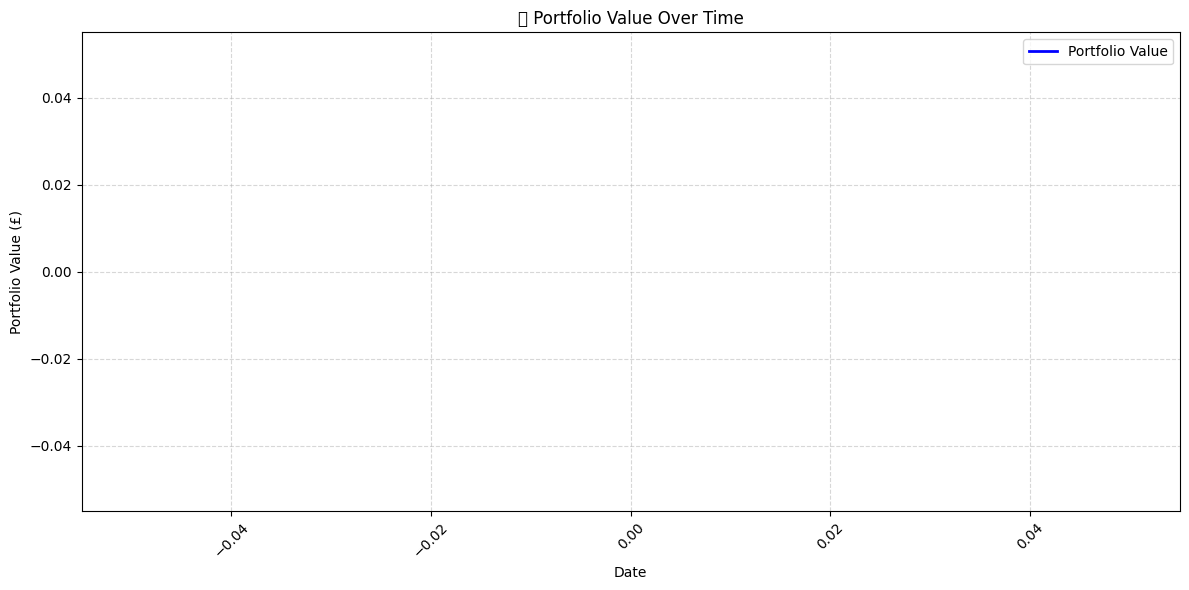

In [42]:
import yfinance as yf
import pandas as pd
from stable_baselines3 import PPO
from stable_baselines3.common.vec_env import DummyVecEnv
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from collections import Counter


# Download BTC data
print("📥 Downloading BTC data...")
btc_data = yf.download('BTC-USD', start='2018-01-01', end='2024-12-31')
btc_data.reset_index(inplace=True)
btc_data['Ticker'] = 'BTC-USD'
print("✅ BTC data downloaded.")

# Feature engineering (simplified, replace with your real pipeline)
btc_data['Close_rolling_max_21'] = btc_data['Close'].rolling(window=21).max()
btc_data['Close_rolling_min_21'] = btc_data['Close'].rolling(window=21).min()
btc_data['Close_rolling_std_21'] = btc_data['Close'].rolling(window=21).std()
btc_data['Close_rolling_avg_21'] = btc_data['Close'].rolling(window=21).mean()
btc_data['Close_rsi'] = btc_data['Close'].pct_change().rolling(14).mean()  # placeholder RSI
btc_data['Close_macd'] = btc_data['Close'].ewm(span=12).mean() - btc_data['Close'].ewm(span=26).mean()
btc_data['Close_macd_signal'] = btc_data['Close_macd'].ewm(span=9).mean()

# Drop NaNs
btc_data = btc_data.dropna().reset_index(drop=True)

# Train-test split
train_df = btc_data[btc_data['Date'] < '2022-01-01'].copy()
test_df = btc_data[btc_data['Date'] >= '2022-01-01'].copy()

# Define features
feature_cols = [
    'Close', 'Volume', 'Close_rolling_max_21', 'Close_rolling_min_21',
    'Close_rolling_std_21', 'Close_rolling_avg_21', 'Close_rsi',
    'Close_macd', 'Close_macd_signal'
]

# Create environments
train_env = DummyVecEnv([lambda: CryptoTradingEnv(train_df, feature_cols=feature_cols, multi_ticker=False)])
test_env = DummyVecEnv([lambda: CryptoTradingEnv(test_df, feature_cols=feature_cols, multi_ticker=False)])

def plot_portfolio_growth(env):
    dates = env.data['Date'].iloc[:len(env.portfolio_value_history)]
    values = env.portfolio_value_history

    plt.figure(figsize=(12, 6))
    plt.plot(dates, values, label="Portfolio Value", linewidth=2, color='blue')
    plt.title("📈 Portfolio Value Over Time")
    plt.xlabel("Date")
    plt.ylabel("Portfolio Value (£)")
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.legend()
    plt.show()

# Train model
model = PPO("MlpPolicy", train_env, verbose=1)
model.learn(total_timesteps=1000)
model.save("ppo_btc_model")

# Test model
obs = test_env.reset()
done = [False] * test_env.num_envs
portfolio_values = []
actions_taken = []

# Run until all environments are done
while not all(done):
    action, _ = model.predict(obs, deterministic=True)
    obs, rewards, done, infos = test_env.step(action)

    for i in range(test_env.num_envs):
        info = infos[i]
        date = info.get("date", "❓")
        pval = info.get("portfolio_value", "MISSING")

        print(f"Step | Date: {date} | Value: {pval}")

    if pval is not None and pval != "MISSING":
        portfolio_values.append(pval)

    for i in range(test_env.num_envs):
        if infos[i].get("portfolio_value") is not None:
            portfolio_values.append(infos[i]["portfolio_value"])
        actions_taken.append(int(action[i]))

# Convert list to array
portfolio_values = np.array(portfolio_values)
print(f"✅ Collected {portfolio_values.shape[0]} portfolio values with shape {portfolio_values.shape}.")

# Ensure portfolio values were collected
if portfolio_values.size > 0:
    print("plotting portfolio growth...")
    plot_portfolio_growth(test_env.envs[0])
else:
    print("⚠️ No portfolio values were recorded. Check `info['portfolio_value']` in your env.")